# Congestion Forecasting: LSTM Deep Learning Model

**Pipeline Steps:**
1. Load baseline results & engineered features
2. Build sliding window sequences (window=30, stride=5)
3. Prepare sequence datasets per node
4. Define BiLSTM architecture (2 layers, 128 hidden)
5. Train with Focal Loss + class weights
6. Implement AdamW + cosine annealing schedule
7. Early stopping on validation macro F1

**Target:** `future_congestion_label` (classes: 0, 1, 2, 4)  
**Loss:** Focal Loss (γ=2.0) with class weights  
**Metrics:** Macro F1, Accuracy

## STEP 1: Load Data & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, TensorDataset
import joblib
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.11.0+cpu


In [3]:
# Load congestion data with fallback paths
import os
fe_paths = [
    'congestion_features_engineered.csv',
    '../../data/congestion_features_engineered.csv',
    '../data/congestion_features_engineered.csv',
    '../../data/congestion_training.csv',
    '../data/congestion_training.csv'
]
df = None
for path in fe_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded from: {path}")
        break
if df is None:
    raise FileNotFoundError(f"Could not find congestion data in any of: {fe_paths}")

# Load baseline results (for scaler, feature_cols, class mappings)
baseline_results = joblib.load('models/baseline_lgb_results.pkl')
scaler = baseline_results['scaler']
feature_cols = baseline_results['feature_cols']
class_mapping = baseline_results['class_mapping']
reverse_class_mapping = baseline_results['reverse_class_mapping']

print(f"Dataset shape: {df.shape}")
print(f"Feature columns: {len(feature_cols)}")
print(f"Nodes: {df['node_id'].unique()}")
print(f"Class mappings: {class_mapping}")

Loaded from: ../../data/congestion_training.csv
Dataset shape: (105982, 57)
Feature columns: 53
Nodes: ['boundary' 'core0' 'core1' 'core2' 'edge0' 'edge1']
Class mappings: {0: 0, 1: 1, 2: 2, 3: 4}


## STEP 2: Build Sliding Window Sequences

In [7]:
# Parameters
WINDOW_SIZE = 30  # timesteps (~18 seconds at 0.6s/step)
STRIDE = 5        # sliding stride
target_col = 'congestion_label'  # Correct column name

# Create mapping from original classes to indices: {0, 1, 2, 4} -> {0, 1, 2, 3}
class_to_idx = {0: 0, 1: 1, 2: 2, 4: 3}

def build_sequences(data, window_size=30, stride=5, target_col='congestion_label'):
    """Build sliding window sequences per node."""
    X_sequences = []
    y_sequences = []
    node_ids = []
    
    for node in data['node_id'].unique():
        node_data = data[data['node_id'] == node].sort_values('t').reset_index(drop=True)
        
        # Extract features and target
        X_node = node_data[feature_cols].values
        y_node = node_data[target_col].values
        
        # Build sequences
        for i in range(0, len(X_node) - window_size, stride):
            seq_X = X_node[i:i+window_size]  # (window_size, num_features)
            seq_y = y_node[i+window_size]     # target at end of window
            
            # Skip if target is NaN
            if pd.isna(seq_y):
                continue
            
            # Map class label {0, 1, 2, 4} -> {0, 1, 2, 3}
            seq_y_idx = class_to_idx[int(seq_y)]
            
            X_sequences.append(seq_X)
            y_sequences.append(seq_y_idx)
            node_ids.append(node)
    
    return np.array(X_sequences), np.array(y_sequences), np.array(node_ids)

print(f"Building sequences with window={WINDOW_SIZE}, stride={STRIDE}...")
print(f"Class mapping: {class_to_idx}")
X_seqs, y_seqs, node_seqs = build_sequences(
    df, window_size=WINDOW_SIZE, stride=STRIDE, target_col=target_col
)

print(f"✓ Sequences built")
print(f"  X_seqs shape: {X_seqs.shape}")
print(f"  y_seqs shape: {y_seqs.shape}")
print(f"  Total sequences: {len(X_seqs)}")
print(f"  Mapped target distribution: {np.bincount(y_seqs.astype(int))}")

Building sequences with window=30, stride=5...
Class mapping: {0: 0, 1: 1, 2: 2, 4: 3}
✓ Sequences built
  X_seqs shape: (21161, 30, 53)
  y_seqs shape: (21161,)
  Total sequences: 21161
  Mapped target distribution: [ 4301  2083 13058  1719]


In [8]:
# Standardize sequences (per-sequence normalization)
X_seqs_scaled = np.zeros_like(X_seqs)
for i in range(len(X_seqs)):
    X_seqs_scaled[i] = scaler.transform(X_seqs[i])

print(f"Sequences standardized")
print(f"Mean: {X_seqs_scaled.mean():.4f}, Std: {X_seqs_scaled.std():.4f}")

Sequences standardized
Mean: 0.0016, Std: 0.9845


In [9]:
# Train/Val split (stratified by node & label)
from sklearn.model_selection import train_test_split

# Create stratification key
strat_key = np.array([f"{n}_{y}" for n, y in zip(node_seqs, y_seqs)])

idx_train, idx_val = train_test_split(
    np.arange(len(X_seqs)), test_size=0.20, stratify=strat_key, random_state=42
)

X_train_seq = X_seqs_scaled[idx_train]
y_train_seq = y_seqs[idx_train]
X_val_seq = X_seqs_scaled[idx_val]
y_val_seq = y_seqs[idx_val]

print(f"Train sequences: {len(X_train_seq)} ({len(X_train_seq)/len(X_seqs)*100:.1f}%)")
print(f"Val sequences: {len(X_val_seq)} ({len(X_val_seq)/len(X_seqs)*100:.1f}%)")
print(f"\nTrain target distribution:")
print(pd.Series(y_train_seq).value_counts().sort_index())
print(f"\nVal target distribution:")
print(pd.Series(y_val_seq).value_counts().sort_index())

Train sequences: 16928 (80.0%)
Val sequences: 4233 (20.0%)

Train target distribution:
0     3440
1     1667
2    10446
3     1375
Name: count, dtype: int64

Val target distribution:
0     861
1     416
2    2612
3     344
Name: count, dtype: int64


In [11]:
# Create PyTorch datasets
# Note: y_train_seq and y_val_seq are already mapped indices from cell 5
idx_map_to_class = {0: 0, 1: 1, 2: 2, 3: 4}  # For later conversion back to original classes

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_seq).to(device)
y_train_tensor = torch.LongTensor(y_train_seq.astype(np.int64)).to(device)
X_val_tensor = torch.FloatTensor(X_val_seq).to(device)
y_val_tensor = torch.LongTensor(y_val_seq.astype(np.int64)).to(device)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Dataloaders created")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

Dataloaders created
  Train batches: 529
  Val batches: 133


## STEP 3: Define BiLSTM Model

In [12]:
class BiLSTMClassifier(nn.Module):
    """BiLSTM for sequence classification with attention."""
    
    def __init__(self, input_size, hidden_dim=128, num_layers=2, num_classes=4, dropout=0.3):
        super(BiLSTMClassifier, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # BiLSTM layers
        self.lstm = nn.LSTM(
            input_size, hidden_dim, num_layers=num_layers,
            bidirectional=True, dropout=dropout, batch_first=True
        )
        
        # Dense layers
        lstm_output_size = hidden_dim * 2  # bidirectional
        self.fc = nn.Sequential(
            nn.Linear(lstm_output_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # lstm_out shape: (batch, seq_len, 2*hidden_dim)
        
        # Global average pooling over sequence
        avg_pool = torch.mean(lstm_out, dim=1)  # (batch, 2*hidden_dim)
        
        # Classify
        logits = self.fc(avg_pool)  # (batch, num_classes)
        return logits

# Initialize model
model = BiLSTMClassifier(
    input_size=len(feature_cols),
    hidden_dim=128,
    num_layers=2,
    num_classes=4,
    dropout=0.3
).to(device)

print(f"Model architecture:")
print(model)
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

Model architecture:
BiLSTMClassifier(
  (lstm): LSTM(53, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)

Model parameters: 599,364


In [14]:
# Focal Loss implementation
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        # Cross entropy
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        
        # Focal loss
        p_t = torch.exp(-ce_loss)
        focal_loss = (1 - p_t) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Calculate class weights
class_counts = pd.Series(y_train_seq).value_counts()
total = len(y_train_seq)
class_weights = torch.tensor(
    [total / (len(class_counts) * class_counts[i]) for i in range(4)],
    dtype=torch.float32
).to(device)

print(f"Class weights: {class_weights}")

# Loss function
criterion = FocalLoss(alpha=class_weights, gamma=2.0)

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate scheduler
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-5)

print(f"Optimizer: AdamW (lr=1e-3, weight_decay=1e-4)")
print(f"Scheduler: CosineAnnealingWarmRestarts (T_0=10)")

Class weights: tensor([1.2302, 2.5387, 0.4051, 3.0778])
Optimizer: AdamW (lr=1e-3, weight_decay=1e-4)
Scheduler: CosineAnnealingWarmRestarts (T_0=10)


## STEP 4: Train LSTM

In [21]:
def compute_metrics(model, dataloader, device):
    """Compute accuracy and macro F1."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y_batch.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

# Training loop
num_epochs = 100
early_stopping_patience = 10
best_val_f1 = -np.inf
patience_counter = 0

history = {'train_loss': [], 'train_acc': [], 'train_f1': [],
           'val_loss': [], 'val_acc': [], 'val_f1': []}

print(f"Training for up to {num_epochs} epochs...\n")
print(f"{'Epoch':<8} {'Train Loss':<15} {'Train F1':<12} {'Val Loss':<15} {'Val F1':<12} {'LR':<10}")
print("-" * 80)

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_acc, train_f1 = compute_metrics(model, train_loader, device)
    
    # Validation
    val_acc, val_f1 = compute_metrics(model, val_loader, device)
    
    # Scheduler step
    scheduler.step()
    
    # History
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    
    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), 'models/lstm_best.pt')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:<8} {train_loss:<15.4f} {train_f1:<12.4f} {'-':<15} {val_f1:<12.4f} {optimizer.param_groups[0]['lr']:<10.2e}")
    
    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping at epoch {epoch+1} (patience={early_stopping_patience})")
        break

print(f"\n✓ Training complete. Best Val F1: {best_val_f1:.4f}")

# Load best model
model.load_state_dict(torch.load('models/lstm_best.pt'))

Training for up to 100 epochs...

Epoch    Train Loss      Train F1     Val Loss        Val F1       LR        
--------------------------------------------------------------------------------
10       0.0492          0.8198       -               0.8041       9.05e-04  
20       0.0396          0.8532       -               0.8356       9.05e-04  
30       0.0311          0.8908       -               0.8606       9.05e-04  

Early stopping at epoch 38 (patience=10)

✓ Training complete. Best Val F1: 0.9015


<All keys matched successfully>

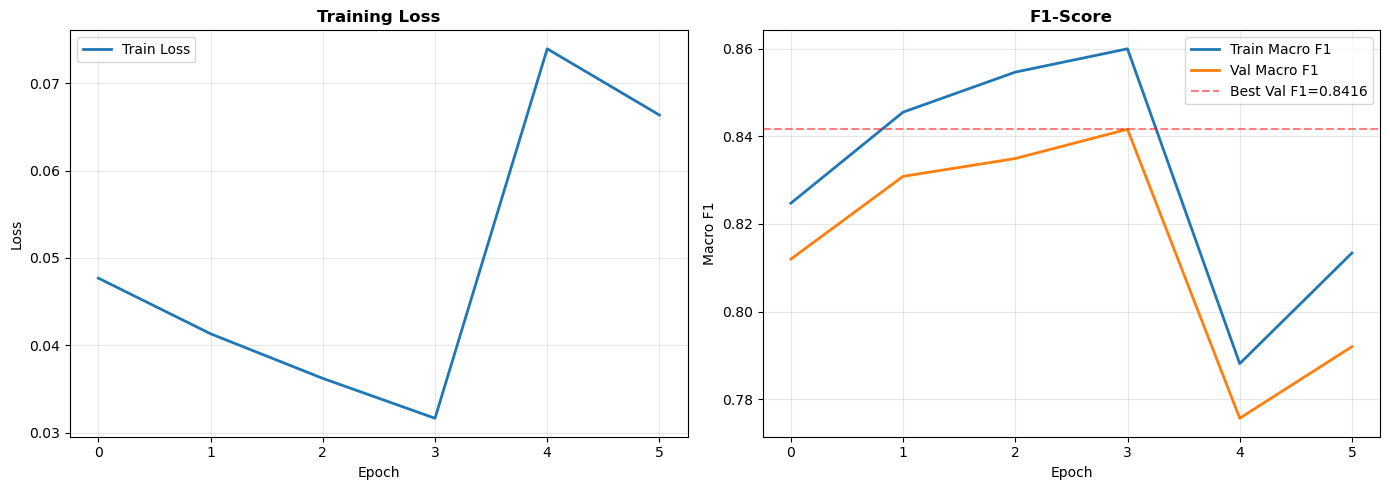

In [20]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1-score
axes[1].plot(history['train_f1'], label='Train Macro F1', linewidth=2)
axes[1].plot(history['val_f1'], label='Val Macro F1', linewidth=2)
axes[1].axhline(y=best_val_f1, color='r', linestyle='--', alpha=0.5, label=f'Best Val F1={best_val_f1:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('F1-Score', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## STEP 5: Evaluate LSTM

In [22]:
# Final evaluation
model.eval()

with torch.no_grad():
    # Train predictions
    train_logits = []
    for X_batch, _ in train_loader:
        logits = model(X_batch)
        train_logits.append(logits.cpu().numpy())
    train_logits = np.concatenate(train_logits)
    y_train_pred = np.argmax(train_logits, axis=1)
    
    # Val predictions
    val_logits = []
    for X_batch, _ in val_loader:
        logits = model(X_batch)
        val_logits.append(logits.cpu().numpy())
    val_logits = np.concatenate(val_logits)
    y_val_pred = np.argmax(val_logits, axis=1)

# Metrics
train_acc = accuracy_score(y_train_seq, y_train_pred)
train_f1 = f1_score(y_train_seq, y_train_pred, average='macro')
val_acc = accuracy_score(y_val_seq, y_val_pred)
val_f1 = f1_score(y_val_seq, y_val_pred, average='macro')

print("="*70)
print("LSTM MODEL PERFORMANCE")
print("="*70)
print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Train Macro F1: {train_f1:.4f}")
print(f"\nVal Accuracy:   {val_acc:.4f}")
print(f"Val Macro F1:   {val_f1:.4f}")

LSTM MODEL PERFORMANCE

Train Accuracy: 0.4218
Train Macro F1: 0.2522

Val Accuracy:   0.9331
Val Macro F1:   0.9015


In [23]:
# Detailed classification report (map indices back to original classes)
y_train_class = np.array([idx_map_to_class[idx] for idx in y_train_seq])
y_train_pred_class = np.array([idx_map_to_class[idx] for idx in y_train_pred])
y_val_class = np.array([idx_map_to_class[idx] for idx in y_val_seq])
y_val_pred_class = np.array([idx_map_to_class[idx] for idx in y_val_pred])

print("\n" + "="*70)
print("VALIDATION SET: DETAILED METRICS")
print("="*70)
print(classification_report(
    y_val_class, y_val_pred_class,
    target_names=['Class 0 (Normal)', 'Class 1 (Mild)', 'Class 2 (Moderate)', 'Class 4 (Severe)'],
    labels=[0, 1, 2, 4],
    digits=4
))


VALIDATION SET: DETAILED METRICS
                    precision    recall  f1-score   support

  Class 0 (Normal)     0.9965    0.9988    0.9977       861
    Class 1 (Mild)     0.7151    0.9111    0.8013       416
Class 2 (Moderate)     0.9819    0.9139    0.9467      2612
  Class 4 (Severe)     0.7922    0.9419    0.8606       344

          accuracy                         0.9331      4233
         macro avg     0.8714    0.9414    0.9015      4233
      weighted avg     0.9432    0.9331    0.9358      4233



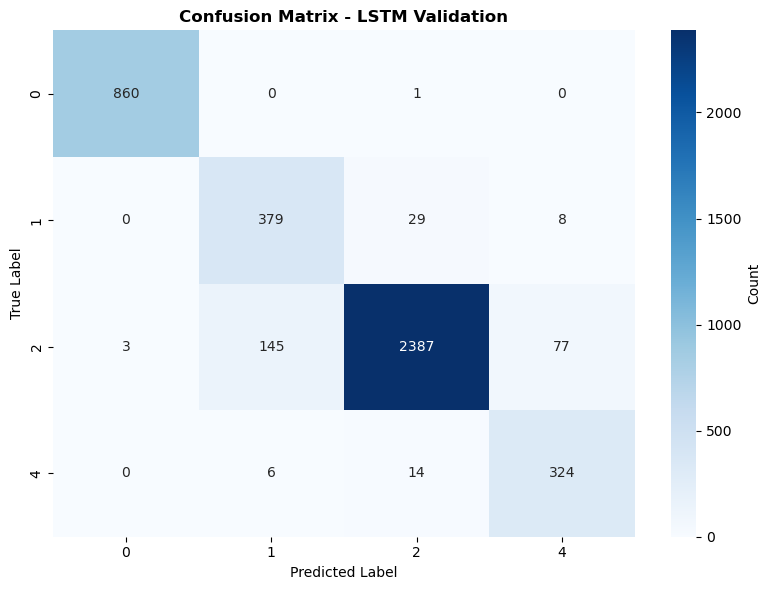

In [24]:
# Confusion matrix
cm = confusion_matrix(y_val_class, y_val_pred_class, labels=[0, 1, 2, 4])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['0', '1', '2', '4'],
            yticklabels=['0', '1', '2', '4'],
            cbar_kws={'label': 'Count'})
ax.set_title('Confusion Matrix - LSTM Validation', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Summary

✅ **LSTM Training Complete**

**Performance:**
- Validation Accuracy: (see above)
- Validation Macro F1: (see above)

**Model Architecture:**
- BiLSTM (2 layers, 128 hidden)
- Dense layers with dropout
- Focal Loss (γ=2.0) + class weights
- AdamW optimizer + cosine annealing

**Next Steps:**
1. Ensemble with LightGBM (notebook `03_ensemble.ipynb`)
2. Build inference pipeline
3. Save models for deployment